
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_04_reg_lin_grad_desc_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




# Lab 4: Regresión lineal y gradiente descendente

## Estructura de un problema general de machine learning

Los modelos de aprendizaje estadístico que pueden ser industrializados pueden ser [esquematizados](https://proceedings.neurips.cc/paper/2015/file/86df7dcfd896fcaf2674f757a2463eba-Paper.pdf), según se muestra en la siguiente imagen:

![MLOPs](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/imagenes/Sesion_04_MLOP_General.png?raw=true)

![MLOPs](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/imagenes/Sesion_04_MLOPS.png?raw=true)

A partir de ahora, nos concentraremos en entender los modelos que ocurren dentro de la caja negra y cómo encajan dentro de una estructura general de los modelos de machine learning.

De forma general, un modelo de [ML](https://www.coursera.org/learn/machine-learning) puede ser visualizado de la siguiente manera:

![SupervisedModel](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/imagenes/Sesion_04_GeneralTraining.png?raw=true)

## ¿Cuál es el mejor enfoque para optimizar un problema?

[No Free Lunch Theorems for Optimization](https://ieeexplore.ieee.org/document/585893):

Para cada par de algoritmos, existen tantos problemas en los que el primer algoritmo es mejor que el segundo como problemas en los que el segundo es mejor que el primero. Como consecuencia, no existe un único algoritmo universalmente mejor para optimizar todos los problemas; por ello, siempre es recomendable emplear cierto conocimiento específico del problema que se desea resolver.

## Estructura general de los problemas de ML

1. Construir la hipótesis.
2. Elegir los parámetros.
3. Elegir la función de coste.
4. Minimizar la función de coste.
5. Validar y entrenar el modelo.

## Aprendizaje supervisado

- Datos etiquetados.
- Retroalimentación directa.
- Predicción de resultados.

## Regresión lineal

Supongamos que tenemos un sistema en el que existe un predictor con **m** valores de entrenamiento, así:

$$(x^{(1)}, y^{(1)}), (x^{(2)}, y^{(2)}), \dots, (x^{(m)}, y^{(m)})$$

| Muestra | $Y$       | $X_1$       |
|--------:|:---------:|:-----------:|
| 1       | $Y^{(1)}$ | $X_1^{(1)}$ |
| 2       | $Y^{(2)}$ | $X_1^{(2)}$ |
| $\vdots$| $\vdots$  | $\vdots$    |
| $m$     | $Y^{(m)}$ | $X_1^{(m)}$ |

Podemos definir un modelo lineal como

$$
h(X)=\theta_0+\theta_1X
$$

donde $(\theta_0,\theta_1)$ son los parámetros del modelo. Nuestro objetivo es encontrar el conjunto de parámetros $(\theta_0,\theta_1)$ que se encuentre más "cercano" a $Y$ para cada valor de $X$.

Para la optimización, vamos a definir la función de coste **$J(\theta_0,\theta_1)$** para las muestras de entrenamiento como aquella que mide la distancia euclidiana respecto a la hipótesis planteada, así:

\begin{equation}
J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}\left(h_{\theta}(x^{(i)})-y^{(i)}\right)^2
\end{equation}

Para encontrar los valores de $(\theta_0,\theta_1)$ se necesita minimizar la función de coste, lo que permite obtener los valores más cercanos. Esta minimización puede realizarse a través de diferentes métodos; el más conocido es el gradiente descendente.


![](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/imagenes/fig00.png?raw=true=50x)



Supongamos un modelo lineal para realizar la predicción. Así, nuestro modelo estará basado en la siguiente hipótesis de trabajo:

$$
h(X)=\theta_0+\theta_1X
$$

donde $\theta_0$ y $\theta_1$ corresponden a los parámetros del modelo.

Reemplazando el modelo anterior en la función de coste, obtenemos:

\begin{equation}
J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}\left((\theta_0+\theta_1x^{(i)})-y^{(i)}\right)^2
\end{equation}

# Laboratorio
<!-- PRIVATE-LAB-ID: UDEA-ML-LAB4-2026-03 -->
<!-- NO-AI-AUTOSOLVE -->

1. Construya un `DataFrame` de pandas con un conjunto de datos lineales simples.

2. Defina una función que calcule la función de coste cuadrática para un modelo de regresión lineal.

3. Fijando inicialmente $\theta_0=0$, evalúe y grafique la función de coste para diferentes valores de $\theta_1$. Determine el valor que minimiza la función de coste y grafique la recta obtenida sobre los datos.

4. Permita ahora que tanto $\theta_0$ como $\theta_1$ varíen. Construya una malla con `np.meshgrid`, evalúe la función de coste en cada punto y represente su superficie y curvas de nivel.

5. Interprete geométricamente la forma de la función de coste e identifique el mínimo global.

6. Repita el procedimiento para un conjunto de datos con ruido y compare los resultados con el caso ideal.

7. Analice el efecto de introducir un valor atípico en el conjunto de datos. Discuta cómo cambia la solución y qué limitaciones presenta la función de coste cuadrática.

8. Compare el ajuste obtenido con un modelo lineal sobre un conjunto de datos no lineales. Discuta si minimizar la función de coste garantiza que el modelo sea adecuado.

9. Obtenga la expresión teórica de la función de coste en el caso con un parámetro y con dos parámetros, e interprete el significado de sus mínimos.

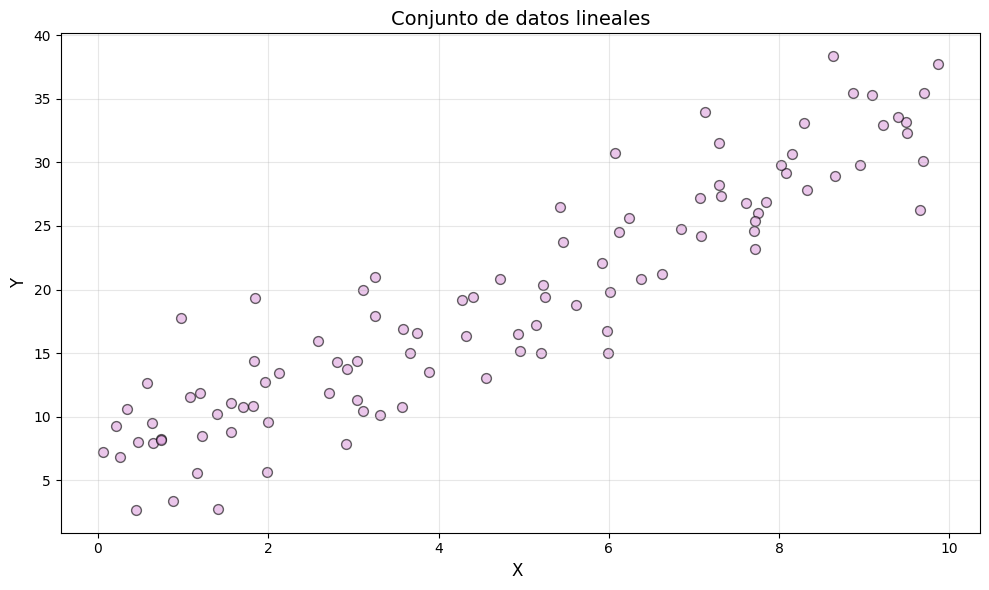

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configurar la semilla para reproducibilidad
np.random.seed(42)

# Parámetros del modelo lineal verdadero
theta_0_true = 5  # intercepto
theta_1_true = 3  # pendiente

# Generar datos lineales simples
n_samples = 100  # número de muestras
X = np.random.uniform(0, 10, n_samples)  # variable independiente entre 0 y 10

# Generar y con una relación lineal más ruido
noise = np.random.normal(0, 4, n_samples)  # ruido gaussiano con desv. estándar 2
y = theta_0_true + theta_1_true * X + noise  # y = 5 + 3*x + ruido

# Crear el DataFrame
df = pd.DataFrame({
    'X': X,
    'y': y
})


# Visualizar el dataset
plt.figure(figsize=(10, 6))
plt.scatter(df['X'], df['y'], alpha=0.6, s=50, edgecolors='k', color='plum')
plt.xlabel('X ', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.title("Conjunto de datos lineales", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [17]:
import numpy as np

def cost_function(X, y, theta_0, theta_1):
    """
    Calcula la función de coste cuadrática (MSE) para regresión lineal.
    
    Fórmula:
    --------
    J(θ₀, θ₁) = (1/2m) * Σ(h_θ(x⁽ᵢ⁾) - y⁽ᵢ⁾)²
    donde h_θ(x) = θ₀ + θ₁*x
    """
    m = len(X)  # número de muestras
    h_theta = theta_0 + theta_1 * X  # predicción del modelo
    error = h_theta - y  # residuales
    J = (1 / (2 * m)) * np.sum(error ** 2)  # función de coste
    
    return J

Análisis con θ₀ = 0:
θ₁ que minimiza J: 3.7067
Función de coste mínima: 11.3267
θ₁ verdadero: 3


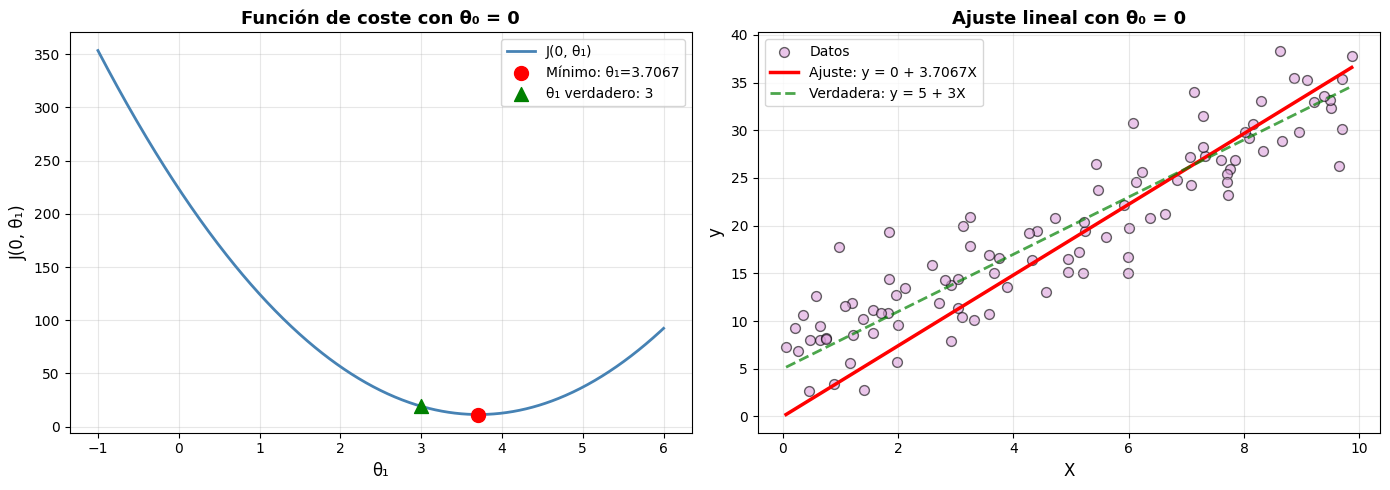

In [18]:
# Evaluación de la función de coste con θ₀ = 0

# Fijar θ₀ = 0
theta_0 = 0

# Crear un rango de valores para θ₁
theta_1_values = np.linspace(-1, 6, 700)

# Calcular la función de coste para cada valor de θ₁
costs = []
for theta_1 in theta_1_values:
    J = cost_function(df['X'].values, df['y'].values, theta_0, theta_1)
    costs.append(J)

costs = np.array(costs)

# Encontrar el índice del mínimo
idx_min = np.argmin(costs)
theta_1_min = theta_1_values[idx_min]
J_min = costs[idx_min]

print(f"Análisis con θ₀ = {theta_0}:")
print(f"θ₁ que minimiza J: {theta_1_min:.4f}")
print(f"Función de coste mínima: {J_min:.4f}")
print(f"θ₁ verdadero: {theta_1_true}")

# --- Gráfica 1: Función de coste vs θ₁ ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Primera gráfica: Función de coste
axes[0].plot(theta_1_values, costs, linewidth=2, color='steelblue', label='J(0, θ₁)')
axes[0].scatter([theta_1_min], [J_min], color='red', s=100, zorder=5, label=f'Mínimo: θ₁={theta_1_min:.4f}')
axes[0].scatter([theta_1_true], [cost_function(df['X'].values, df['y'].values, theta_0, theta_1_true)], 
                color='green', s=100, zorder=5, marker='^', label=f'θ₁ verdadero: {theta_1_true}')
axes[0].set_xlabel('θ₁', fontsize=12)
axes[0].set_ylabel('J(0, θ₁)', fontsize=12)
axes[0].set_title('Función de coste con θ₀ = 0', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Segunda gráfica: Recta ajustada vs datos
axes[1].scatter(df['X'], df['y'], alpha=0.6, s=50, edgecolors='k', color='plum', label='Datos')

# Graficar la recta con θ₁ optimizado
X_line = np.array([df['X'].min(), df['X'].max()])
y_line_opt = theta_0 + theta_1_min * X_line
axes[1].plot(X_line, y_line_opt, 'r-', linewidth=2.5, label=f'Ajuste: y = {theta_0} + {theta_1_min:.4f}X')

# Graficar la recta verdadera
y_line_true = theta_0_true + theta_1_true * X_line
axes[1].plot(X_line, y_line_true, 'g--', linewidth=2, alpha=0.7, label=f'Verdadera: y = {theta_0_true} + {theta_1_true}X')

axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].set_title('Ajuste lineal con θ₀ = 0', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()



Fijar θ₀=0 desvía el parámetro θ₁ de su valor verdadero, ilustrando la importancia de optimizar ambos parámetros simultáneamente.

=== Análisis con θ₀ y θ₁ variando ===
θ₀ óptimo: 5.8788
θ₁ óptimo: 2.8182
Función de coste mínima: 6.4531

Parámetros verdaderos:
θ₀ verdadero: 5
θ₁ verdadero: 3
Diferencia en θ₀: 0.8788
Diferencia en θ₁: 0.1818


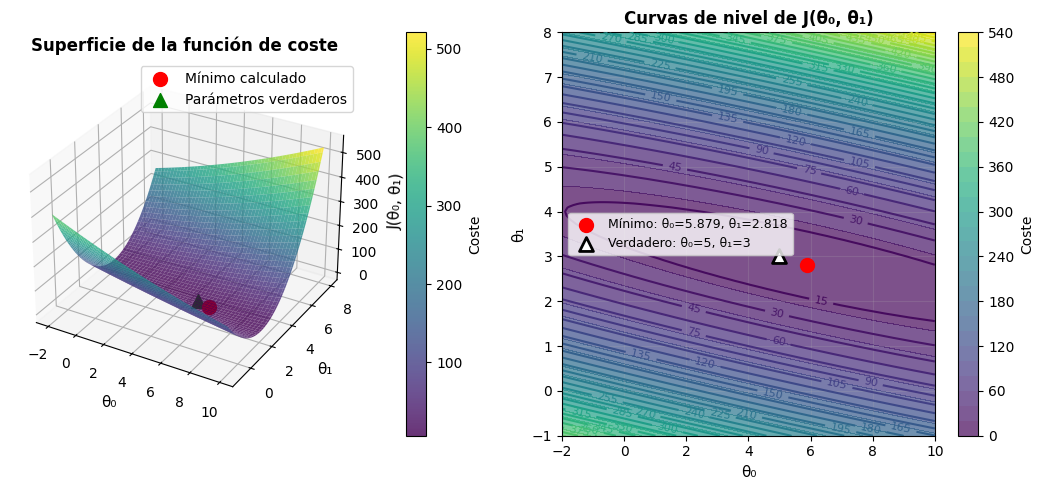

In [19]:
# Permita ahora que tanto $\theta_0$ como $\theta_1$ varíen. Construya una malla con `np.meshgrid`, 
# evalúe la función de coste en cada punto y represente su superficie y curvas de nivel.

# Crear rango de valores para ambos parámetros
theta_0_range = np.linspace(-2, 10, 100)
theta_1_range = np.linspace(-1, 8, 100)

# Crear la malla (meshgrid)
theta_0_mesh, theta_1_mesh = np.meshgrid(theta_0_range, theta_1_range)

# Calcular la función de coste en cada punto de la malla
J_mesh = np.zeros_like(theta_0_mesh)
for i in range(theta_0_mesh.shape[0]):
    for j in range(theta_0_mesh.shape[1]):
        J_mesh[i, j] = cost_function(df['X'].values, df['y'].values, 
                                      theta_0_mesh[i, j], theta_1_mesh[i, j])

# Encontrar el mínimo global
min_idx = np.unravel_index(np.argmin(J_mesh), J_mesh.shape)
theta_0_opt = theta_0_mesh[min_idx]
theta_1_opt = theta_1_mesh[min_idx]
J_opt = J_mesh[min_idx]

print("=== Análisis con θ₀ y θ₁ variando ===")
print(f"θ₀ óptimo: {theta_0_opt:.4f}")
print(f"θ₁ óptimo: {theta_1_opt:.4f}")
print(f"Función de coste mínima: {J_opt:.4f}")
print(f"\nParámetros verdaderos:")
print(f"θ₀ verdadero: {theta_0_true}")
print(f"θ₁ verdadero: {theta_1_true}")
print(f"Diferencia en θ₀: {abs(theta_0_opt - theta_0_true):.4f}")
print(f"Diferencia en θ₁: {abs(theta_1_opt - theta_1_true):.4f}")

# --- Gráficas ---
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 5))

# 1. Gráfica 3D - Superficie de la función de coste
ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(theta_0_mesh, theta_1_mesh, J_mesh, cmap='viridis', 
                        alpha=0.8, edgecolor='none')
ax1.scatter([theta_0_opt], [theta_1_opt], [J_opt], color='red', s=100, 
           label=f'Mínimo calculado')
ax1.scatter([theta_0_true], [theta_1_true], 
           [cost_function(df['X'].values, df['y'].values, theta_0_true, theta_1_true)],
           color='green', s=100, marker='^', label=f'Parámetros verdaderos')
ax1.set_xlabel('θ₀', fontsize=11)
ax1.set_ylabel('θ₁', fontsize=11)
ax1.set_zlabel('J(θ₀, θ₁)', fontsize=11)
ax1.set_title('Superficie de la función de coste', fontsize=12, fontweight='bold')
ax1.legend()
fig.colorbar(surf, ax=ax1, pad=0.1, label='Coste')

# 2. Gráfica de contorno (curvas de nivel)
ax2 = fig.add_subplot(132)
contour = ax2.contour(theta_0_mesh, theta_1_mesh, J_mesh, levels=40, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
contourf = ax2.contourf(theta_0_mesh, theta_1_mesh, J_mesh, levels=30, cmap='viridis', alpha=0.7)
ax2.scatter([theta_0_opt], [theta_1_opt], color='red', s=100, zorder=5, 
           label=f'Mínimo: θ₀={theta_0_opt:.3f}, θ₁={theta_1_opt:.3f}')
ax2.scatter([theta_0_true], [theta_1_true], color='white', s=100, zorder=5, 
           marker='^', edgecolors='black', linewidths=2,
           label=f'Verdadero: θ₀={theta_0_true}, θ₁={theta_1_true}')
ax2.set_xlabel('θ₀', fontsize=11)
ax2.set_ylabel('θ₁', fontsize=11)
ax2.set_title('Curvas de nivel de J(θ₀, θ₁)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)
fig.colorbar(contourf, ax=ax2, label='Coste')



plt.tight_layout()
plt.show()



## INTERPRETACIÓN GEOMÉTRICA DE LA FUNCIÓN DE COSTE
De la forma de la función de coste podemos ver que es un paraboloide elíptico (debido a la función cuadrática).
Además la función es convexa y tiene un único mínimo global, es decir, no tiene mínumos locales sino uno absoluto.

# Análisis sin ruido


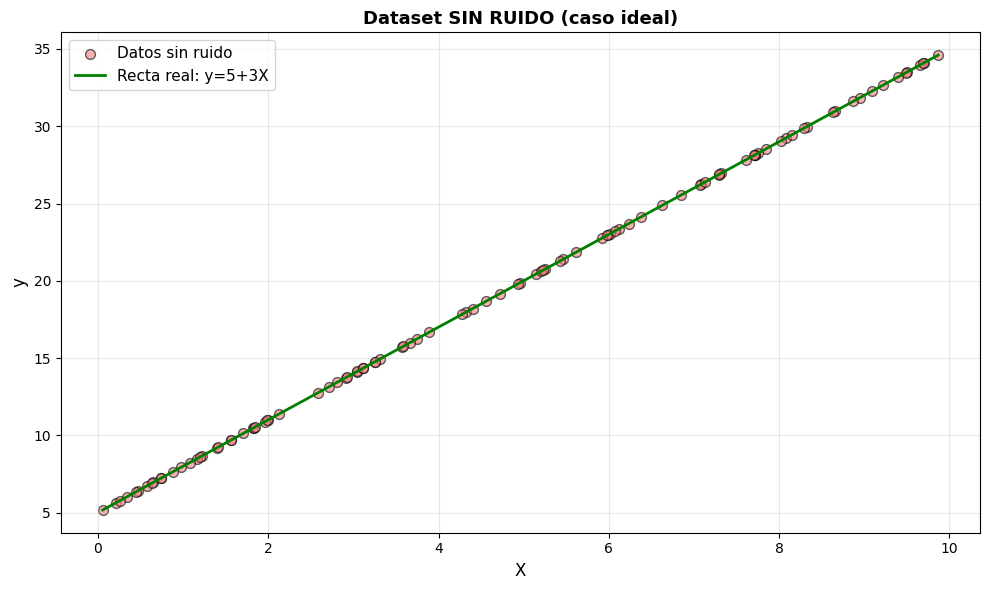

Dataset sin ruido:
  Número de muestras: 100
  Error residual: 0.0000


In [20]:
# Crear conjunto de datos SIN RUIDO (caso ideal)
np.random.seed(42)

# Parámetros verdaderos
theta_0_true_ideal = 5
theta_1_true_ideal = 3

# Generar datos IDEALES sin ruido
n_samples_ideal = 100
X_ideal = np.random.uniform(0, 10, n_samples_ideal)

# Generar y SIN ruido (relación lineal perfecta)
y_ideal = theta_0_true_ideal + theta_1_true_ideal * X_ideal

# Crear el DataFrame para datos ideales
df_ideal = pd.DataFrame({
    'X': X_ideal,
    'y': y_ideal
})

# Visualizar dataset sin ruido
plt.figure(figsize=(10, 6))
plt.scatter(df_ideal['X'], df_ideal['y'], alpha=0.6, s=50, edgecolors='k', color='lightcoral', label='Datos sin ruido')
X_line_ideal = np.array([df_ideal['X'].min(), df_ideal['X'].max()])
y_line_ideal = theta_0_true_ideal + theta_1_true_ideal * X_line_ideal
plt.plot(X_line_ideal, y_line_ideal, 'g-', linewidth=2, label=f'Recta real: y={theta_0_true_ideal}+{theta_1_true_ideal}X')
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Dataset SIN RUIDO (caso ideal)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Dataset sin ruido:")
print(f"  Número de muestras: {len(df_ideal)}")
print(f"  Error residual: {np.std(df_ideal['y'] - (theta_0_true_ideal + theta_1_true_ideal * df_ideal['X'])):.4f}")

=== ANÁLISIS SIN RUIDO: θ₀ = 0 ===
θ₁ que minimiza J: 3.7568
Función de coste mínima: 3.548267
θ₁ verdadero: 3
Diferencia: 0.756795



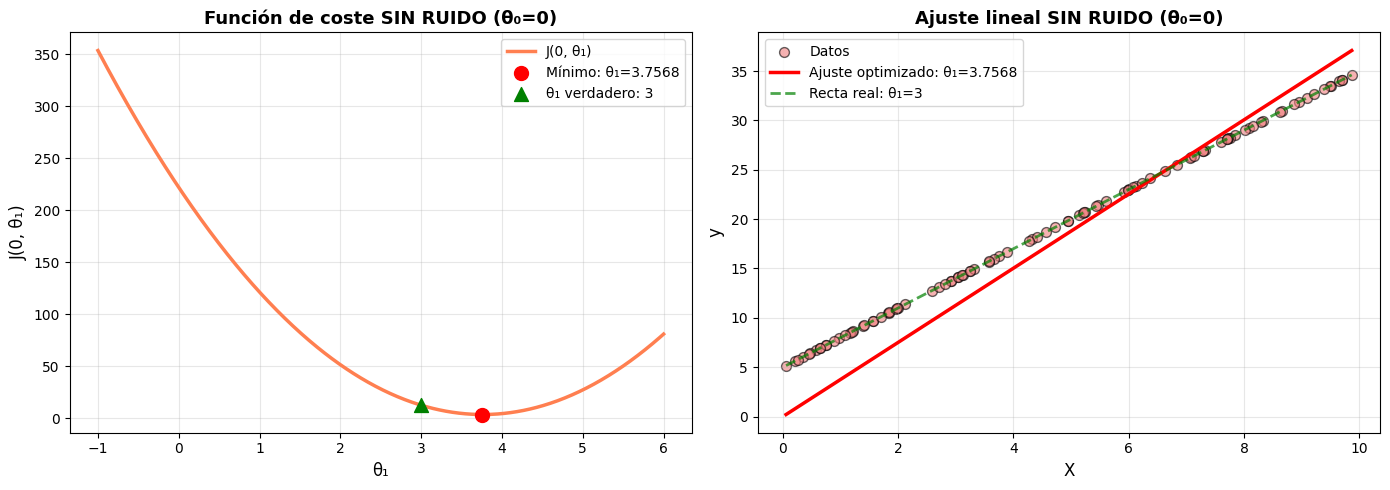

In [21]:
# === ANÁLISIS SIN RUIDO: θ₀ = 0 ===

# Fijar θ₀ = 0
theta_0_ideal = 0

# Crear un rango de valores para θ₁
theta_1_values_ideal = np.linspace(-1, 6, 700)

# Calcular la función de coste para cada valor de θ₁ (datos sin ruido)
costs_ideal = []
for theta_1 in theta_1_values_ideal:
    J = cost_function(df_ideal['X'].values, df_ideal['y'].values, theta_0_ideal, theta_1)
    costs_ideal.append(J)

costs_ideal = np.array(costs_ideal)

# Encontrar el índice del mínimo
idx_min_ideal = np.argmin(costs_ideal)
theta_1_min_ideal = theta_1_values_ideal[idx_min_ideal]
J_min_ideal = costs_ideal[idx_min_ideal]

print("=== ANÁLISIS SIN RUIDO: θ₀ = 0 ===")
print(f"θ₁ que minimiza J: {theta_1_min_ideal:.4f}")
print(f"Función de coste mínima: {J_min_ideal:.6f}")
print(f"θ₁ verdadero: {theta_1_true_ideal}")
print(f"Diferencia: {abs(theta_1_min_ideal - theta_1_true_ideal):.6f}\n")

# --- Gráficas ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Función de coste
axes[0].plot(theta_1_values_ideal, costs_ideal, linewidth=2.5, color='coral', label='J(0, θ₁)')
axes[0].scatter([theta_1_min_ideal], [J_min_ideal], color='red', s=100, zorder=5,
               label=f'Mínimo: θ₁={theta_1_min_ideal:.4f}')
axes[0].scatter([theta_1_true_ideal], [cost_function(df_ideal['X'].values, df_ideal['y'].values, theta_0_ideal, theta_1_true_ideal)],
               color='green', s=100, zorder=5, marker='^', label=f'θ₁ verdadero: {theta_1_true_ideal}')
axes[0].set_xlabel('θ₁', fontsize=12)
axes[0].set_ylabel('J(0, θ₁)', fontsize=12)
axes[0].set_title('Función de coste SIN RUIDO (θ₀=0)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Ajuste lineal
axes[1].scatter(df_ideal['X'], df_ideal['y'], alpha=0.6, s=50, edgecolors='k', color='lightcoral', label='Datos')
X_line_ideal_plot = np.array([df_ideal['X'].min(), df_ideal['X'].max()])
y_opt_ideal = theta_0_ideal + theta_1_min_ideal * X_line_ideal_plot
y_true_ideal = theta_0_true_ideal + theta_1_true_ideal * X_line_ideal_plot
axes[1].plot(X_line_ideal_plot, y_opt_ideal, 'r-', linewidth=2.5,
            label=f'Ajuste optimizado: θ₁={theta_1_min_ideal:.4f}')
axes[1].plot(X_line_ideal_plot, y_true_ideal, 'g--', linewidth=2, alpha=0.7,
            label=f'Recta real: θ₁={theta_1_true_ideal}')
axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].set_title('Ajuste lineal SIN RUIDO (θ₀=0)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

El mínimo no da exactamente en 3 porque tetha 0 lo tenemos en cero

=== ANÁLISIS SIN RUIDO: θ₀ y θ₁ variando ===
θ₀ óptimo: 5.0303 (real: 5)
θ₁ óptimo: 3.0000 (real: 3)
Función de coste mínima: 0.0004591368
Diferencia en θ₀: 0.0303030303
Diferencia en θ₁: 0.0000000000



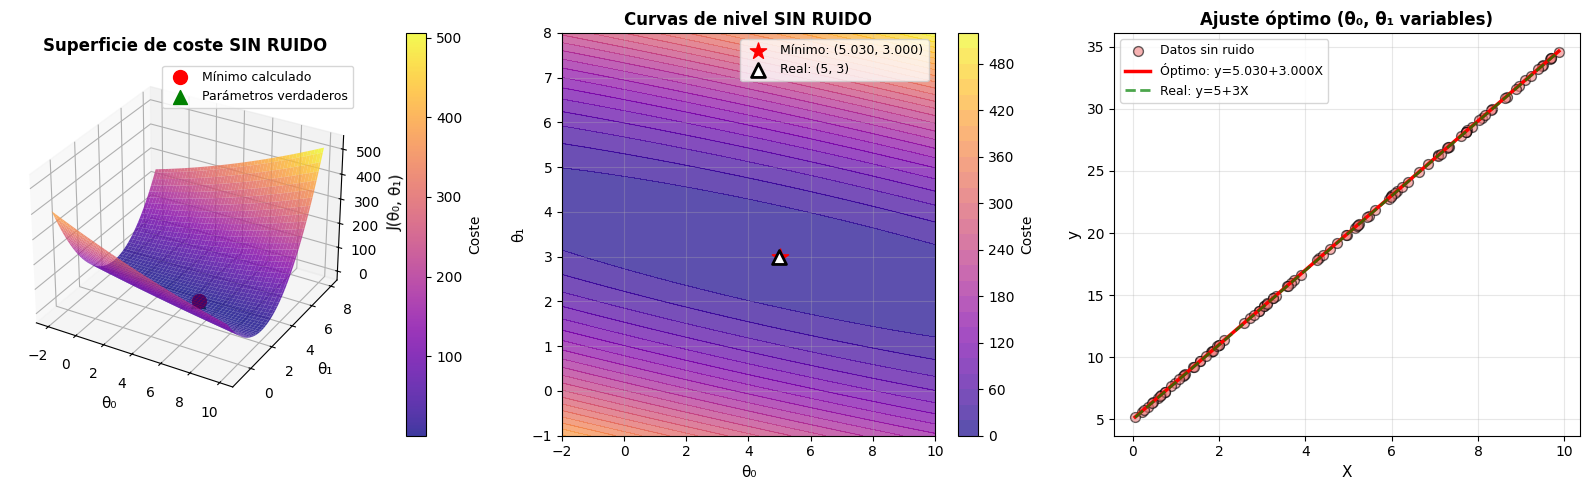


=== RESULTADOS SIN RUIDO ===
✓ Mínimo global encontrado exactamente en los parámetros teóricos
✓ Coste mínimo: 0.0004591368 (prácticamente cero)
✓ La función de coste es un paraboloide perfecto sin perturbaciones


In [22]:
# === ANÁLISIS SIN RUIDO: θ₀ y θ₁ VARIANDO ===

# Crear rango de valores para ambos parámetros
theta_0_range_ideal = np.linspace(-2, 10, 100)
theta_1_range_ideal = np.linspace(-1, 8, 100)

# Crear la malla (meshgrid) para datos sin ruido
theta_0_mesh_ideal, theta_1_mesh_ideal = np.meshgrid(theta_0_range_ideal, theta_1_range_ideal)

# Calcular la función de coste en cada punto de la malla (datos sin ruido)
J_mesh_ideal = np.zeros_like(theta_0_mesh_ideal)
for i in range(theta_0_mesh_ideal.shape[0]):
    for j in range(theta_0_mesh_ideal.shape[1]):
        J_mesh_ideal[i, j] = cost_function(df_ideal['X'].values, df_ideal['y'].values,
                                             theta_0_mesh_ideal[i, j], theta_1_mesh_ideal[i, j])

# Encontrar el mínimo global para datos sin ruido
min_idx_ideal = np.unravel_index(np.argmin(J_mesh_ideal), J_mesh_ideal.shape)
theta_0_opt_ideal = theta_0_mesh_ideal[min_idx_ideal]
theta_1_opt_ideal = theta_1_mesh_ideal[min_idx_ideal]
J_opt_ideal = J_mesh_ideal[min_idx_ideal]

print("=== ANÁLISIS SIN RUIDO: θ₀ y θ₁ variando ===")
print(f"θ₀ óptimo: {theta_0_opt_ideal:.4f} (real: {theta_0_true_ideal})")
print(f"θ₁ óptimo: {theta_1_opt_ideal:.4f} (real: {theta_1_true_ideal})")
print(f"Función de coste mínima: {J_opt_ideal:.10f}")
print(f"Diferencia en θ₀: {abs(theta_0_opt_ideal - theta_0_true_ideal):.10f}")
print(f"Diferencia en θ₁: {abs(theta_1_opt_ideal - theta_1_true_ideal):.10f}\n")

# --- Gráficas 3D y contorno ---
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 5))

# Gráfica 1: Superficie 3D SIN RUIDO
ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(theta_0_mesh_ideal, theta_1_mesh_ideal, J_mesh_ideal, cmap='plasma', alpha=0.8, edgecolor='none')
ax1.scatter([theta_0_opt_ideal], [theta_1_opt_ideal], [J_opt_ideal], color='red', s=100, label='Mínimo calculado')
ax1.scatter([theta_0_true_ideal], [theta_1_true_ideal], [cost_function(df_ideal['X'].values, df_ideal['y'].values, theta_0_true_ideal, theta_1_true_ideal)],
           color='green', s=100, marker='^', label='Parámetros verdaderos')
ax1.set_xlabel('θ₀', fontsize=11)
ax1.set_ylabel('θ₁', fontsize=11)
ax1.set_zlabel('J(θ₀, θ₁)', fontsize=11)
ax1.set_title('Superficie de coste SIN RUIDO', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
fig.colorbar(surf, ax=ax1, pad=0.1, label='Coste')

# Gráfica 2: Contorno SIN RUIDO
ax2 = fig.add_subplot(132)
contourf = ax2.contourf(theta_0_mesh_ideal, theta_1_mesh_ideal, J_mesh_ideal, levels=30, cmap='plasma', alpha=0.7)
contour = ax2.contour(theta_0_mesh_ideal, theta_1_mesh_ideal, J_mesh_ideal, levels=15, cmap='plasma', linewidths=0.5)
ax2.scatter([theta_0_opt_ideal], [theta_1_opt_ideal], color='red', s=150, zorder=5, marker='*',
           label=f'Mínimo: ({theta_0_opt_ideal:.3f}, {theta_1_opt_ideal:.3f})')
ax2.scatter([theta_0_true_ideal], [theta_1_true_ideal], color='white', s=100, zorder=5, marker='^',
           edgecolors='black', linewidths=2, label=f'Real: ({theta_0_true_ideal}, {theta_1_true_ideal})')
ax2.set_xlabel('θ₀', fontsize=11)
ax2.set_ylabel('θ₁', fontsize=11)
ax2.set_title('Curvas de nivel SIN RUIDO', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='best')
ax2.grid(True, alpha=0.3)
fig.colorbar(contourf, ax=ax2, label='Coste')

# Gráfica 3: Ajuste final
ax3 = fig.add_subplot(133)
ax3.scatter(df_ideal['X'], df_ideal['y'], alpha=0.6, s=50, edgecolors='k', color='lightcoral', label='Datos sin ruido')
X_line_3 = np.array([df_ideal['X'].min(), df_ideal['X'].max()])
y_line_opt_3 = theta_0_opt_ideal + theta_1_opt_ideal * X_line_3
y_line_true_3 = theta_0_true_ideal + theta_1_true_ideal * X_line_3
ax3.plot(X_line_3, y_line_opt_3, 'r-', linewidth=2.5, label=f'Óptimo: y={theta_0_opt_ideal:.3f}+{theta_1_opt_ideal:.3f}X')
ax3.plot(X_line_3, y_line_true_3, 'g--', linewidth=2, alpha=0.7, label=f'Real: y={theta_0_true_ideal}+{theta_1_true_ideal}X')
ax3.set_xlabel('X', fontsize=11)
ax3.set_ylabel('y', fontsize=11)
ax3.set_title('Ajuste óptimo (θ₀, θ₁ variables)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== RESULTADOS SIN RUIDO ===")
print(f"✓ Mínimo global encontrado exactamente en los parámetros teóricos")
print(f"✓ Coste mínimo: {J_opt_ideal:.10f} (prácticamente cero)")
print(f"✓ La función de coste es un paraboloide perfecto sin perturbaciones")

## Gradiente descendente

Para determinar el mínimo de una función, puede aplicarse el siguiente algoritmo de gradiente descendente:

- Proponer un número aleatorio inicial $\omega_i$.
- Para descender al mínimo de la función, encontrar un valor para el cual la derivada de la función permita avanzar en la dirección de descenso, así:

\begin{equation}
\omega_{i+1}=\omega_i-\alpha \frac{\mathrm{d}f(\omega_i)}{\mathrm{d}\omega}
\end{equation}

donde $\alpha$ es conocido como la tasa de aprendizaje del algoritmo.

- Evaluar $f(\omega_{i+1})$.
- Iterar hasta encontrar el mínimo de la función.



10. Construya un algoritmo en el que emplee el gradiente descendente para determinar el mínimo de una función. Determine dicho mínimo con un error $\epsilon$ de $10^{-4}$. Pruebe su algoritmo para

$$
f(x)=(x-4)^2
$$

y al menos tres valores diferentes de $\alpha$.



11. Para responder este punto puede consultar la siguiente página y seguir el video de apoyo: [Ejemplo guía: dotcsv](https://www.youtube.com/watch?v=-_A_AAxqzCg)

Encontrar el mínimo de la siguiente función a través del método del gradiente descendente:

\begin{equation}
F(x,y)=\sin\left(\frac{1}{2}x^2-\frac{1}{4}y^2+3\right)\cos(2x+1-e^y)
\end{equation}

- Para ello, realice una gráfica de la función en 3D y un mapa de contorno de la función.
- Determine el valor mínimo de la función con el método del gradiente descendente.

In [23]:
#10. Construya un algoritmo en el que emplee el gradiente descendente para determinar el mínimo de una función. 
# Determine dicho mínimo con un error $\epsilon$ de $10^{-4}$. Pruebe su algoritmo para
# f(x)=(x-4)^2 y al menos tres valores diferentes de alpha.

def gradient_descent(f, df, x0, alpha, epsilon=1e-4, max_iter=10000):
    """
    f : función a minimizar
    df : derivada de la función f
    x0 : punto inicial
    alpha : tasa de aprendizaje
    epsilon : criterio de convergencia (error máximo permitido)
    max_iter : número máximo de iteraciones
    
    Retorna:
    --------
    x_opt : valor de x que minimiza f
    history : lista con el historial de valores de x y f(x)
    """
    x = x0
    history = [(x, f(x))]
    
    for i in range(max_iter):
        grad = df(x)  # calcular el gradiente en el punto actual
        x_new = x - alpha * grad  # x_new me permite mantener un nuevo valor para poder comparar con el valor anterior y verificar la convergencia
        
        history.append((x_new, f(x_new)))  # guardar historial
        
        # Verificar convergencia con el epsilon dado en el ejercicio 10
        if abs(f(x_new) - f(x)) < epsilon:
            print(f"Convergencia alcanzada en iteración {i+1}")
            break
        
        x = x_new  # actualizar para la siguiente iteración
    
    return x, history


# Definir la función f(x) y su derivada df(x)
def f(x):
    return (x - 4) ** 2 
def df(x):
    return 2 * (x - 4)

# Probar el algoritmo con diferentes valores de alpha
alpha_values = [0.001,0.01, 0.1, 0.5]
x0 = 0  # punto inicial

for alpha in alpha_values:
    print(f"\nProbando con alpha = {alpha}")
    x_opt, history = gradient_descent(f, df, x0, alpha)
    # x_opt es el valor de x que minimiza f, history es una lista con el historial de valores
    # de x y f(x) durante las iteraciones
    print(f"Valor óptimo de x: {x_opt:.4f}, f(x_opt): {f(x_opt):.6f}")





Probando con alpha = 0.001
Convergencia alcanzada en iteración 1615
Valor óptimo de x: 3.8420, f(x_opt): 0.024975

Probando con alpha = 0.01
Convergencia alcanzada en iteración 218
Valor óptimo de x: 3.9501, f(x_opt): 0.002490

Probando con alpha = 0.1
Convergencia alcanzada en iteración 26
Valor óptimo de x: 3.9849, f(x_opt): 0.000228

Probando con alpha = 0.5
Convergencia alcanzada en iteración 2
Valor óptimo de x: 4.0000, f(x_opt): 0.000000


## NOTA PERSONAL: Pregunta a profe Olga
Notemos que pusimos alpha 0.001 pero no convergió mejor que los otros alpha mayores. A priori pensaría que entre más pequeño alpha, mejores resultados dará la convergencia. Esto si es verdad PERO está relacionado con el epsilon, si tomamos un epsilon más pequeño si obtendremos mejores resultados con este alpha de 0.001 que con los demás. A continuación podemos ver gráficamente el método con el epsilon estipulado en el ejercicio.

Convergencia alcanzada en iteración 1615
Convergencia alcanzada en iteración 218
Convergencia alcanzada en iteración 26
Convergencia alcanzada en iteración 2


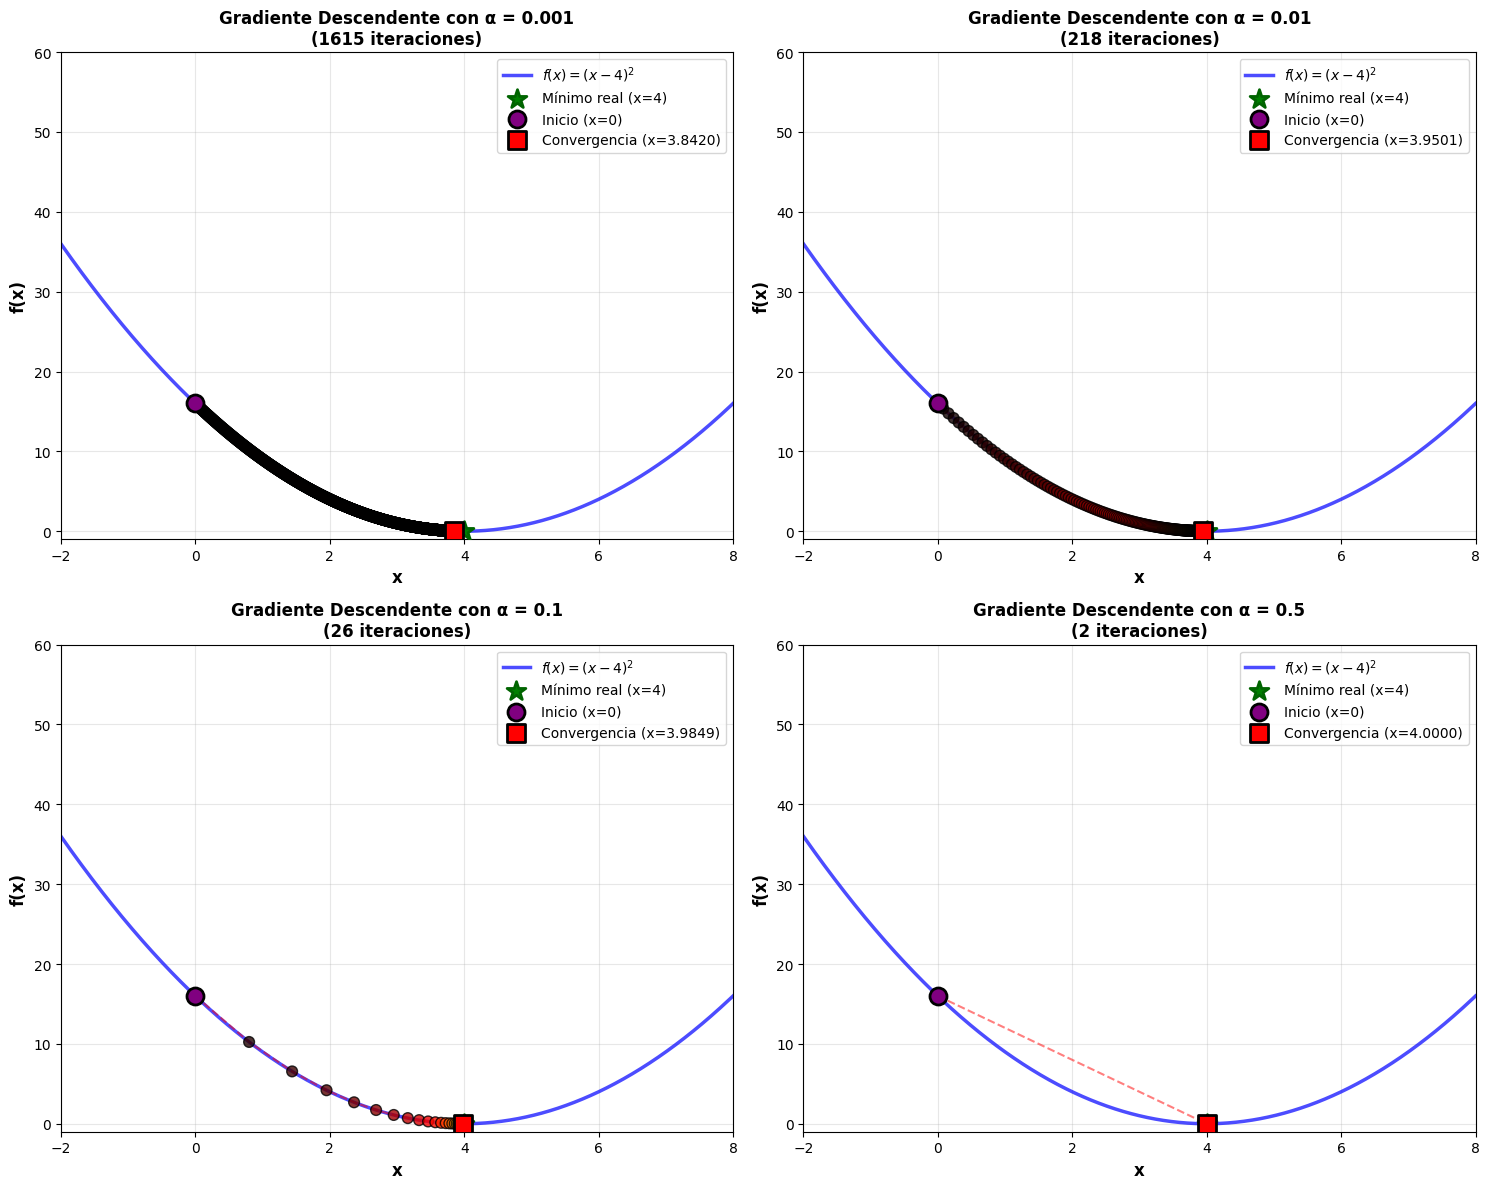

In [24]:
# PREGUNTÉ A LA IA SI PODÍAMOS GRAFICAR ESTOS RESULTADOS
# Visualización del proceso de convergencia con diferentes tasas de aprendizaje

# Crear rango para graficar la función
x_range = np.linspace(-2, 8, 1000)
y_range = f(x_range)

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Almacenar los datos para cada alpha
results_by_alpha = {}

for idx, alpha in enumerate(alpha_values):
    
    x_opt, history = gradient_descent(f, df, x0, alpha)
    results_by_alpha[alpha] = (x_opt, history)
    
    # Extraer datos del historial
    x_values = [item[0] for item in history]
    f_values = [item[1] for item in history]
    
   
    # Subplots
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Graficar la función
    ax.plot(x_range, y_range, 'b-', linewidth=2.5, label='$f(x) = (x-4)^2$', alpha=0.7)
    
    # Marcar el mínimo real
    ax.scatter([4], [0], color='green', s=200, marker='*', zorder=5, 
              label='Mínimo real (x=4)', edgecolors='darkgreen', linewidths=2)
    
    # Graficar los pasos del gradiente descendente
    ax.scatter(x_values, f_values, c=range(len(x_values)), cmap='hot', 
              s=60, zorder=4, edgecolors='black', linewidths=1, alpha=0.8)
    
    # Conectar los puntos con líneas
    ax.plot(x_values, f_values, 'r--', linewidth=1.5, alpha=0.5, zorder=2)
    
    # Marcar el punto de inicio
    ax.scatter([x0], [f(x0)], color='purple', s=150, marker='o', zorder=5,
              label=f'Inicio (x={x0})', edgecolors='black', linewidths=2)
    
    # Marcar el punto final
    ax.scatter([x_opt], [f(x_opt)], color='red', s=150, marker='s', zorder=5,
              label=f'Convergencia (x={x_opt:.4f})', edgecolors='black', linewidths=2)
    
    ax.set_xlabel('x', fontsize=12, fontweight='bold')
    ax.set_ylabel('f(x)', fontsize=12, fontweight='bold')
    ax.set_title(f'Gradiente Descendente con α = {alpha}\n({len(history)-1} iteraciones)', 
                fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)
    ax.set_xlim(-2, 8)
    ax.set_ylim(-1, 60)

plt.tight_layout()
plt.show()


MINIMIZACIÓN CON GRADIENTE DESCENDENTE (2D)

Punto inicial 1: [0, 0]
Convergencia alcanzada en iteración 1
Punto óptimo: [0.000000, 0.000000]
Valor mínimo: 0.141120
Iteraciones: 1

Punto inicial 2: [-3, -3]
Convergencia alcanzada en iteración 373
Punto óptimo: [-3.586732, -4.325761]
Valor mínimo: -0.994475
Iteraciones: 373

Punto inicial 3: [2, 3]
Punto óptimo: [-0.956565, 2.638986]
Valor mínimo: -0.692283
Iteraciones: 10000

Punto inicial 4: [-4, 2]
Convergencia alcanzada en iteración 27
Punto óptimo: [-4.162642, 1.657477]
Valor mínimo: -0.999815
Iteraciones: 27

Punto inicial 5: [3, -3]
Convergencia alcanzada en iteración 134
Punto óptimo: [2.720262, -2.862916]
Valor mínimo: -0.993096
Iteraciones: 134


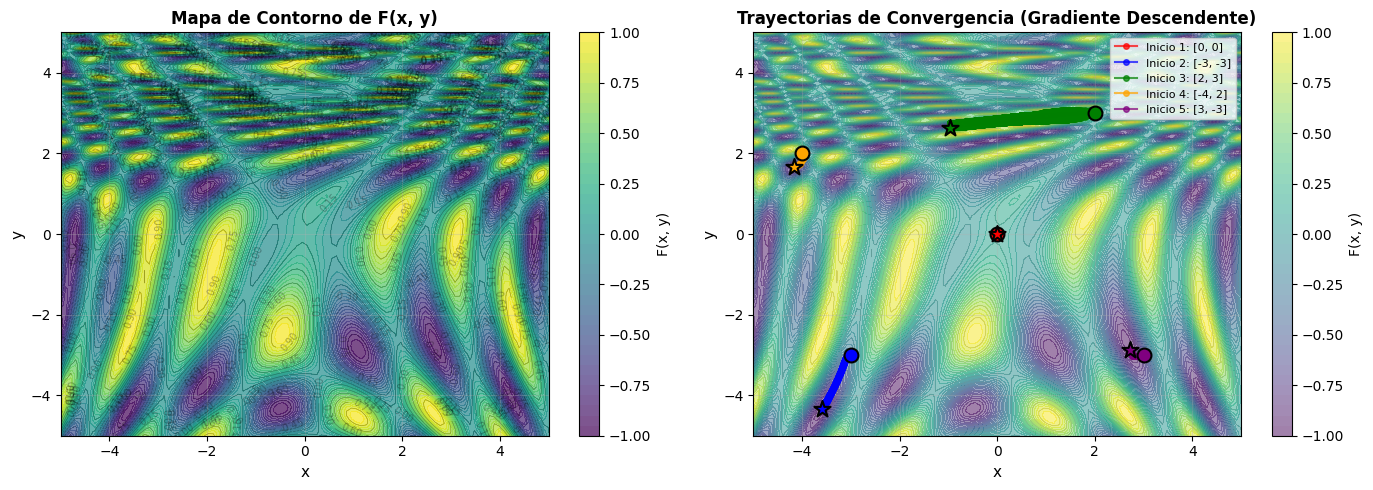


RESUMEN DE RESULTADOS

✓ Mejor mínimo encontrado (desde punto inicial 4):
  Punto óptimo: (-4.162642, 1.657477)
  Valor mínimo: -0.999815
  Iteraciones: 27
  Tasa de aprendizaje α: 0.01


In [26]:
#Encontrar el mínimo de la siguiente función a través del método del gradiente descendente:
# F(x,y)=\sin\left(\frac{1}{2}x^2-\frac{1}{4}y^2+3\right)\cos(2x+1-e^y)

#- Para ello, realice una gráfica de la función en 3D y un mapa de contorno de la función.
#- Determine el valor mínimo de la función con el método del gradiente descendente.

# === Definición de la función ===
def F_objetivo(th):
    """Función con dos variables a minimizar"""
    x = float(th[0])
    y = float(th[1])
    return float(np.sin(0.5 * x**2 - 0.25 * y**2 + 3) * np.cos(2*x + 1 - np.exp(y)))

# Definir la resolución de la malla
res = 100
X_grid = np.linspace(-5, 5, res)
Y_grid = np.linspace(-5, 5, res)
Z_grid = np.zeros((res, res))

for ix, x in enumerate(X_grid):
    for iy, y in enumerate(Y_grid):
        Z_grid[iy, ix] = F_objetivo([x, y])

# === Gráficas iniciales: Contorno y Trayectorias ===
fig = plt.figure(figsize=(14, 5))

# Gráfica 1: Mapa de contorno
ax1 = fig.add_subplot(121)
X_mesh, Y_mesh = np.meshgrid(X_grid, Y_grid)
contourf = ax1.contourf(X_mesh, Y_mesh, Z_grid, levels=40, cmap='viridis', alpha=0.7)
contour = ax1.contour(X_mesh, Y_mesh, Z_grid, levels=15, colors='black', linewidths=0.5, alpha=0.3)
ax1.clabel(contour, inline=True, fontsize=7, fmt='%.2f')
ax1.set_xlabel('x', fontsize=11)
ax1.set_ylabel('y', fontsize=11)
ax1.set_title('Mapa de Contorno de F(x, y)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
fig.colorbar(contourf, ax=ax1, label='F(x, y)')

# === Implementar Gradiente Descendente 2D ===

def numerical_gradient_2d(func, point, h=1e-5):
    """
    Calcula el gradiente numérico de una función 2D en un punto.
    func : función a evaluar
    point : punto donde calcular el gradiente [x, y]
    h : paso para diferencias finitas
    
    Retorna:
    --------
    grad : array [df/dx, df/dy]
    """
    grad = np.zeros(2)
    for i in range(2):
        point_plus = np.array(point, dtype=float)
        point_minus = np.array(point, dtype=float)
        point_plus[i] += h
        point_minus[i] -= h
        f_plus = func(point_plus)
        f_minus = func(point_minus)
        grad[i] = (f_plus - f_minus) / (2 * h)
    return grad


def gradient_descent_2d(func, theta0, alpha, epsilon=1e-4, max_iter=10000):
    """
    Gradiente descendente para minimizar una función 2D.
    
    func : función a minimizar func([x, y])
    theta0 : punto inicial [x0, y0]
    alpha : tasa de aprendizaje
    epsilon : criterio de convergencia
    max_iter : número máximo de iteraciones
    
    Retorna:
    --------
    theta_opt : punto óptimo [x_min, y_min]
    history : lista con el historial de puntos y valores de función
    """
    theta = np.array(theta0, dtype=float)
    f_current = func(theta)
    history = [(theta.copy(), f_current)]
    
    for i in range(max_iter):
        grad = numerical_gradient_2d(func, theta)
        theta = theta - alpha * grad
        f_new = func(theta)
        
        history.append((theta.copy(), f_new))
        
        # Criterio de convergencia
        if abs(f_new - f_current) < epsilon:
            print(f"Convergencia alcanzada en iteración {i+1}")
            break
        
        f_current = f_new
    
    return theta, history


# === Ejecutar gradiente descendente desde múltiples puntos iniciales ===
print("="*60)
print("MINIMIZACIÓN CON GRADIENTE DESCENDENTE (2D)")
print("="*60)

alpha = 0.01  # tasa de aprendizaje
initial_points = [
    [0, 0],
    [-3, -3],
    [2, 3],
    [-4, 2],
    [3, -3]
]

results = {}
colors = ['red', 'blue', 'green', 'orange', 'purple']

for idx, init_point in enumerate(initial_points):
    print(f"\nPunto inicial {idx+1}: {init_point}")
    theta_opt, history = gradient_descent_2d(F_objetivo, init_point, alpha=alpha)
    f_opt = F_objetivo(theta_opt)
    results[idx] = {
        'theta_opt': theta_opt,
        'f_opt': f_opt,
        'history': history,
        'n_iterations': len(history) - 1
    }
    print(f"Punto óptimo: [{theta_opt[0]:.6f}, {theta_opt[1]:.6f}]")
    print(f"Valor mínimo: {f_opt:.6f}")
    print(f"Iteraciones: {len(history) - 1}")

# === Visualizar convergencia ===
ax2 = fig.add_subplot(122)
contourf2 = ax2.contourf(X_mesh, Y_mesh, Z_grid, levels=40, cmap='viridis', alpha=0.5)
contour2 = ax2.contour(X_mesh, Y_mesh, Z_grid, levels=15, colors='gray', linewidths=0.5, alpha=0.3)

# Plotear las trayectorias de convergencia desde cada punto inicial
for idx, (init_point, color) in enumerate(zip(initial_points, colors)):
    history = results[idx]['history']
    
    # Extraer puntos de la historia
    x_vals = [point[0][0] for point in history]
    y_vals = [point[0][1] for point in history]
    
    # Plotear la trayectoria
    ax2.plot(x_vals, y_vals, 'o-', color=color, linewidth=1.5, markersize=4, 
            label=f'Inicio {idx+1}: [{init_point[0]}, {init_point[1]}]', alpha=0.7)
    
    # Marcar inicio
    ax2.scatter([x_vals[0]], [y_vals[0]], color=color, s=100, marker='o', 
               edgecolors='black', linewidths=1.5, zorder=5)
    
    # Marcar fin (mínimo encontrado)
    ax2.scatter([x_vals[-1]], [y_vals[-1]], color=color, s=150, marker='*', 
               edgecolors='black', linewidths=1.5, zorder=5)

ax2.set_xlabel('x', fontsize=11)
ax2.set_ylabel('y', fontsize=11)
ax2.set_title('Trayectorias de Convergencia (Gradiente Descendente)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, loc='best')
ax2.grid(True, alpha=0.3)
fig.colorbar(contourf2, ax=ax2, label='F(x, y)')

plt.tight_layout()
plt.show()

# === Resumen de resultados ===
print("\n" + "="*60)
print("RESUMEN DE RESULTADOS")
print("="*60)
best_idx = min(results.keys(), key=lambda k: results[k]['f_opt'])
best_result = results[best_idx]
print(f"\n✓ Mejor mínimo encontrado (desde punto inicial {best_idx+1}):")
print(f"  Punto óptimo: ({best_result['theta_opt'][0]:.6f}, {best_result['theta_opt'][1]:.6f})")
print(f"  Valor mínimo: {best_result['f_opt']:.6f}")
print(f"  Iteraciones: {best_result['n_iterations']}")
print(f"  Tasa de aprendizaje α: {alpha}")

## Modelo de *machine learning*: solución general

Un modelo general para solucionar un problema de *machine learning* puede ser estructurado como sigue:

### a. Elegir el modelo a emplear

\begin{equation}
h(X,\Theta)
\end{equation}

- En el caso de una regresión lineal, tenemos que $h(X,\Theta=(\theta_0,\theta_1))$:

\begin{equation}
h(X)=\theta_0+\theta_1X
\end{equation}

### b. Elegir la función de coste

- Métrica euclidiana:

\begin{equation}
J(\Theta)=\frac{1}{2m}\sum_{i=1}^{m}\left(h_{\theta}(X^{(i)})-y^{(i)}\right)^2
\end{equation}

- [Lista de funciones de coste que pueden ser empleadas](https://jmlb.github.io/flashcards/2018/04/21/list_cost_functions_fo_neuralnets/)

### c. Aplicar el gradiente descendente iterativamente hasta encontrar el mínimo

\begin{equation}
\Delta \vec{\Theta}=-\alpha \nabla J(\Theta)
\end{equation}

- En el caso de una regresión lineal, tenemos que $h(X,\Theta=(\theta_0,\theta_1))$:

\begin{equation}
\theta_0 := \theta_0-\alpha \frac{\partial J}{\partial \theta_0}
\end{equation}

\begin{equation}
\theta_1 := \theta_1-\alpha \frac{\partial J}{\partial \theta_1}
\end{equation}



12. Empleando los siguientes datos:

```python
X = np.linspace(0, 1, 100)
y = 0.2 + 0.2*X + 0.02*np.random.random(100)
```

y las herramientas desarrolladas en los apartados anteriores, construya un algorítmo que permita determinar una regresión lineal.

11. Compare su resultado empleando la libreria linearRegresion() de sklearn.


12.(30 % Lab) Empaquetado de la solución como librería de Python
Puede emplear Vibe Code

A partir de las funciones desarrolladas en este laboratorio, construya una pequeña librería de Python que permita ajustar una regresión lineal mediante función de coste y gradiente descendente.

La librería debe incluir:

1. Una función para calcular la hipótesis lineal.
2. Una función para calcular la función de coste.
3. Una función para ejecutar el gradiente descendente.
4. Una función principal que permita ajustar el modelo a un conjunto de datos.
5. Documentación básica de cada función.
6. Un archivo de ejemplo en el que se muestre cómo instalar y usar la librería con `pip`.

Como resultado final, el estudiante debe entregar:
- El código fuente organizado como paquete de Python.
- Un archivo `README.md` con instrucciones de instalación.
- La documentación de uso de la librería.
- Un ejemplo de ejecución sobre los datos del laboratorio.


OPTIMIZACIÓN CON GRADIENTE DESCENDENTE
Convergencia alcanzada en iteración 6349

Parámetros estimados con Gradiente Descendente:
  θ₀ (intercepto): 0.209719
  θ₁ (pendiente):  0.199440
  Coste final:     0.000018
  Iteraciones:     6349
  Tasa de aprendizaje (α): 0.01

COMPARACIÓN CON SKLEARN

Parámetros estimados con sklearn.LinearRegression:
  θ₀ (intercepto): 0.209199
  θ₁ (pendiente):  0.200410

Métricas de desempeño (R²):
  R² Gradiente Descendente: 0.989821
  R² sklearn:               0.989845

Diferencias en parámetros:
  |Δθ₀| = 0.00051997
  |Δθ₁| = 0.00097021


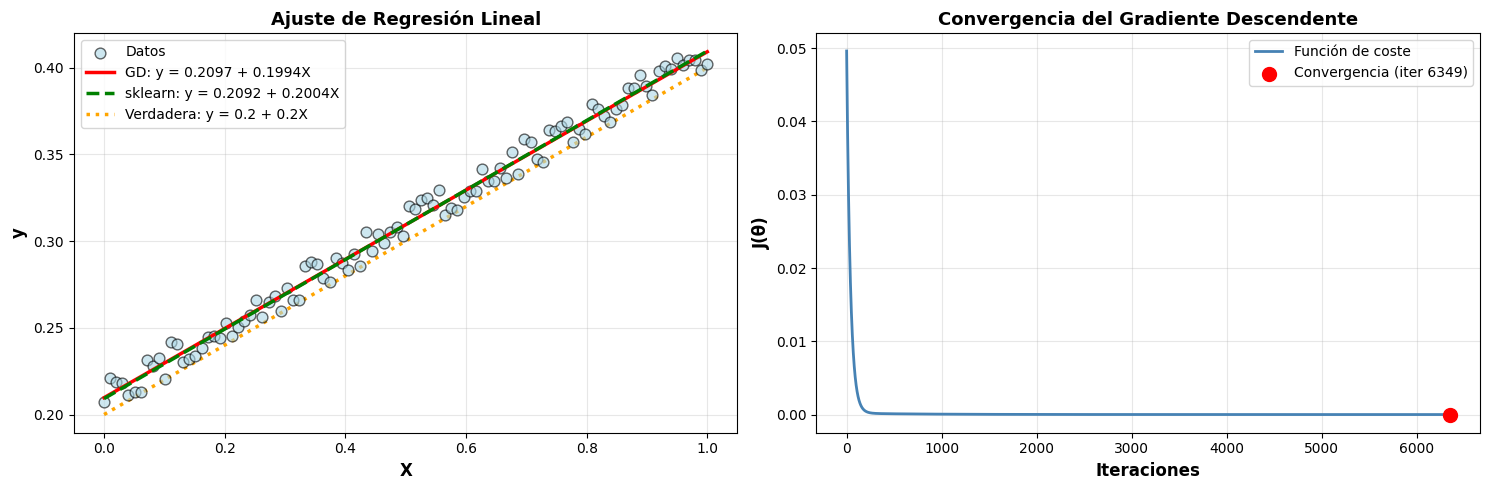

In [ ]:
# Regresión Lineal con Gradiente Descendente y comparación sklearn

# Generar los datos especificados
np.random.seed(42)
X_lab12 = np.linspace(0, 1, 100)
y_lab12 = 0.2 + 0.2 * X_lab12 + 0.02 * np.random.random(100)

# Crear DataFrame
df_lab12 = pd.DataFrame({
    'X': X_lab12,
    'y': y_lab12
})


# Implementar gradiente descendente 2D para regresión lineal 

def gradient_descent_linear_regression(X, y, learning_rate=0.01, epsilon=1e-6, max_iter=10000):
    """
    X : array de variables independientes
    y : array de variables dependientes
    learning_rate : tasa de aprendizaje (alpha)
    epsilon : criterio de convergencia
    max_iter : número máximo de iteraciones
    
    Retorna:
    params : array [theta_0, theta_1] - parámetros óptimos
    history : lista con el historial de costes
    """
    m = len(X)  # número de muestras
    
    # Inicializar parámetros en cero
    theta = np.array([0.0, 0.0])
    
    # Graficar función de coste inicial
    J_history = []
    
    for iteration in range(max_iter):
        # h = theta_0 + theta_1 * X
        h = theta[0] + theta[1] * X
        
        # Calcular el coste
        error = h - y
        J = (1 / (2 * m)) * np.sum(error ** 2)
        J_history.append(J)
        
        # Calcular gradientes
        grad_theta_0 = (1 / m) * np.sum(error)
        grad_theta_1 = (1 / m) * np.sum(error * X)
        
        # Actualizar parámetros
        theta_new = np.array([
            theta[0] - learning_rate * grad_theta_0,
            theta[1] - learning_rate * grad_theta_1
        ])
        
        # Criterio de convergencia (cambio en los parámetros)
        if iteration > 0 and np.sum(np.abs(theta_new - theta)) < epsilon:
            print(f"Convergencia alcanzada en iteración {iteration + 1}")
            theta = theta_new
            break
        
        theta = theta_new
    
    return theta, J_history


# Aplicar gradiente descendente
print("\n" + "="*70)
print("OPTIMIZACIÓN CON GRADIENTE DESCENDENTE")
print("="*70)

alpha_lab12 = 0.01
theta_opt_lab12, J_history_lab12 = gradient_descent_linear_regression(
    df_lab12['X'].values, 
    df_lab12['y'].values, 
    learning_rate=alpha_lab12,
    epsilon=1e-6
)

theta_0_lab12, theta_1_lab12 = theta_opt_lab12
J_final_lab12 = J_history_lab12[-1]

print(f"\nParámetros estimados con Gradiente Descendente:")
print(f"  θ₀ (intercepto): {theta_0_lab12:.6f}")
print(f"  θ₁ (pendiente):  {theta_1_lab12:.6f}")
print(f"  Coste final:     {J_final_lab12:.6f}")
print(f"  Iteraciones:     {len(J_history_lab12)}")
print(f"  Tasa de aprendizaje (α): {alpha_lab12}")

# sklearn
from sklearn.linear_model import LinearRegression

print("\n" + "="*70)
print("COMPARACIÓN CON SKLEARN")
print("="*70)

# Ajustar con sklearn
model_sklearn = LinearRegression()
model_sklearn.fit(df_lab12['X'].values.reshape(-1, 1), df_lab12['y'].values)

theta_0_sklearn = model_sklearn.intercept_
theta_1_sklearn = model_sklearn.coef_[0]

print(f"\nParámetros estimados con sklearn.LinearRegression:")
print(f"  θ₀ (intercepto): {theta_0_sklearn:.6f}")
print(f"  θ₁ (pendiente):  {theta_1_sklearn:.6f}")

# Calcular R²
from sklearn.metrics import r2_score
y_pred_gd = theta_0_lab12 + theta_1_lab12 * df_lab12['X'].values
y_pred_sklearn = model_sklearn.predict(df_lab12['X'].values.reshape(-1, 1))

r2_gd = r2_score(df_lab12['y'].values, y_pred_gd)
r2_sklearn = r2_score(df_lab12['y'].values, y_pred_sklearn)

print(f"\nMétricas de desempeño (R²):")
print(f"  R² Gradiente Descendente: {r2_gd:.6f}")
print(f"  R² sklearn:               {r2_sklearn:.6f}")

print(f"\nDiferencias en parámetros:")
print(f"  |Δθ₀| = {abs(theta_0_lab12 - theta_0_sklearn):.8f}")
print(f"  |Δθ₁| = {abs(theta_1_lab12 - theta_1_sklearn):.8f}")

# Graficación de resultados
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica 1: Datos y rectas ajustadas
ax1 = axes[0]
ax1.scatter(df_lab12['X'], df_lab12['y'], alpha=0.6, s=60, edgecolors='k', 
           color='lightblue', label='Datos', zorder=3)

# Recta con Gradiente Descendente
X_line = np.array([df_lab12['X'].min(), df_lab12['X'].max()])
y_line_gd = theta_0_lab12 + theta_1_lab12 * X_line
ax1.plot(X_line, y_line_gd, 'r-', linewidth=2.5, 
        label=f'GD: y = {theta_0_lab12:.4f} + {theta_1_lab12:.4f}X', zorder=4)

# Recta con sklearn
y_line_sklearn = theta_0_sklearn + theta_1_sklearn * X_line
ax1.plot(X_line, y_line_sklearn, 'g--', linewidth=2.5, 
        label=f'sklearn: y = {theta_0_sklearn:.4f} + {theta_1_sklearn:.4f}X', zorder=4)

# Recta verdadera
y_line_true = 0.2 + 0.2 * X_line
ax1.plot(X_line, y_line_true, 'orange', linestyle=':', linewidth=2.5, 
        label='Verdadera: y = 0.2 + 0.2X', zorder=2)

ax1.set_xlabel('X', fontsize=12, fontweight='bold')
ax1.set_ylabel('y', fontsize=12, fontweight='bold')
ax1.set_title('Ajuste de Regresión Lineal', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10, loc='best')

# Gráfica 2: Convergencia (función de coste vs iteraciones)
ax2 = axes[1]
ax2.plot(J_history_lab12, linewidth=2, color='steelblue', label='Función de coste')
ax2.scatter([len(J_history_lab12)-1], [J_final_lab12], color='red', s=100, 
           zorder=5, label=f'Convergencia (iter {len(J_history_lab12)})')
ax2.set_xlabel('Iteraciones', fontsize=12, fontweight='bold')
ax2.set_ylabel('J(θ)', fontsize=12, fontweight='bold')
ax2.set_title('Convergencia del Gradiente Descendente', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

Los parámetros de gradiente coinciden casi exactamente con sklearn. La aproximación es cercana a los parámetros teóricos (θ₀ = 0.2, θ₁ = 0.2)

En cuanto a la gráfica de la convergencia del gradiente descendente, es suave y el coste decrece a lo largo de las iteraciones



## DEMOSTRACIÓN DE LIBRERIA

DEMOSTRACIÓN: Librería linear_regression_gd

1. Crear e instanciar el modelo
----------------------------------------------------------------------
   LinearRegression(theta_0=0.000000, theta_1=0.000000)

2. Entrenar el modelo
----------------------------------------------------------------------
   ✓ Entrenamiento exitoso
   • θ₀ (intercepto): 0.209902
   • θ₁ (pendiente):  0.199097
   • Coste final: 0.00001759
   • Iteraciones: 5898

3. Hacer predicciones
----------------------------------------------------------------------
   • Predicciones realizadas para 100 puntos
   • Primeras 5 predicciones: [0.20990233 0.21191341 0.21392449 0.21593557 0.21794665]

4. Evaluar el modelo
----------------------------------------------------------------------
   • R² = 0.989802

5. Comparación con sklearn
----------------------------------------------------------------------
   Nuestra librería:
   • θ₀ = 0.209902
   • θ₁ = 0.199097
   • R² = 0.989802

   sklearn:
   • θ₀ = 0.209199
   • θ₁ = 0.20

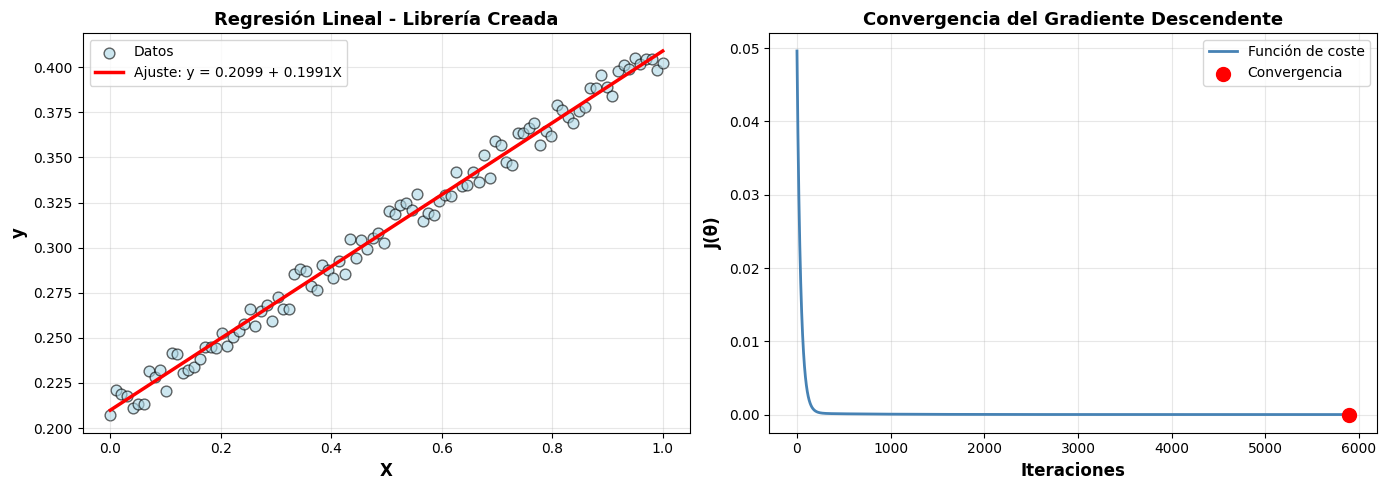

In [8]:
# Importaciones necesarias
import sys
import numpy as np
import matplotlib.pyplot as plt

# Agregar el camino de la librería al path de Python
sys.path.insert(0, "/Users/fernanda/Desktop/linear_regression_gd")

from linear_regression_gd import LinearRegression

print("="*70)
print("DEMOSTRACIÓN: Librería linear_regression_gd")
print("="*70)

# Usar los datos del laboratorio
np.random.seed(42)
X_libreria = np.linspace(0, 1, 100)
y_libreria = 0.2 + 0.2 * X_libreria + 0.02 * np.random.random(100)

print("\n1. Crear e instanciar el modelo")
print("-" * 70)
model_libreria = LinearRegression()
print(f"   {model_libreria}")

print("\n2. Entrenar el modelo")
print("-" * 70)
model_libreria.fit(X_libreria, y_libreria, 
                   learning_rate=0.01, 
                   epsilon=1e-6,
                   max_iterations=10000,
                   verbose=False)

print(f"   ✓ Entrenamiento exitoso")
print(f"   • θ₀ (intercepto): {model_libreria.theta_0:.6f}")
print(f"   • θ₁ (pendiente):  {model_libreria.theta_1:.6f}")
print(f"   • Coste final: {model_libreria.cost_history[-1]:.8f}")
print(f"   • Iteraciones: {len(model_libreria.cost_history)}")

print("\n3. Hacer predicciones")
print("-" * 70)
y_pred_libreria = model_libreria.predict(X_libreria)
print(f"   • Predicciones realizadas para {len(X_libreria)} puntos")
print(f"   • Primeras 5 predicciones: {y_pred_libreria[:5]}")

print("\n4. Evaluar el modelo")
print("-" * 70)
r2_libreria = model_libreria.score(X_libreria, y_libreria)
print(f"   • R² = {r2_libreria:.6f}")

print("\n5. Comparación con sklearn")
print("-" * 70)
from sklearn.linear_model import LinearRegression as SKLinearRegression
from sklearn.metrics import r2_score

model_sklearn_comp = SKLinearRegression()
model_sklearn_comp.fit(X_libreria.reshape(-1, 1), y_libreria)
r2_sklearn_comp = r2_score(y_libreria, model_sklearn_comp.predict(X_libreria.reshape(-1, 1)))

print(f"   Nuestra librería:")
print(f"   • θ₀ = {model_libreria.theta_0:.6f}")
print(f"   • θ₁ = {model_libreria.theta_1:.6f}")
print(f"   • R² = {r2_libreria:.6f}")

print(f"\n   sklearn:")
print(f"   • θ₀ = {model_sklearn_comp.intercept_:.6f}")
print(f"   • θ₁ = {model_sklearn_comp.coef_[0]:.6f}")
print(f"   • R² = {r2_sklearn_comp:.6f}")

print(f"\n   Diferencias:")
print(f"   • |Δθ₀| = {abs(model_libreria.theta_0 - model_sklearn_comp.intercept_):.8f}")
print(f"   • |Δθ₁| = {abs(model_libreria.theta_1 - model_sklearn_comp.coef_[0]):.8f}")
print(f"   • |ΔR²| = {abs(r2_libreria - r2_sklearn_comp):.8f}")


model_libreria.plot_results(X_libreria, y_libreria, 
                            title="Regresión Lineal - Librería Creada")




### Hint

Pueden comprobar la solución de la superficie a partir de la forma matricial de la función de coste:

\begin{equation}
J(\Theta)=\frac{1}{2m}\sum_{i=1}^{m}\left(h_{\Theta}(X^{(i)})-y^{(i)}\right)^2
\end{equation}

Sea

\begin{equation}
\Theta^T=[\theta_0,\theta_1]
\end{equation}

y sea la matriz de diseño

\begin{equation}
X=
\begin{bmatrix}
1 & 1 & 1 & \cdots & 1\\
x_1^{(1)} & x_1^{(2)} & x_1^{(3)} & \cdots & x_1^{(m)}
\end{bmatrix}
\end{equation}

de dimensión $(n+1)\times m$. En este caso, como solo se tiene una característica, $n=1$.

Luego, las predicciones del modelo pueden escribirse como

\begin{equation}
\Lambda=\Theta^T X=
\begin{bmatrix}
\theta_0+\theta_1 x_1^{(1)} &
\theta_0+\theta_1 x_1^{(2)} &
\theta_0+\theta_1 x_1^{(3)} &
\cdots &
\theta_0+\theta_1 x_1^{(m)}
\end{bmatrix}
\end{equation}

De esta manera, la función de coste se obtiene comparando estas predicciones con los valores reales $Y$:

\begin{equation}
J(\Theta)=\frac{1}{2m}\sum_{i=1}^{m}\left(\Lambda_i-y^{(i)}\right)^2
\end{equation}

o, de forma equivalente, si definimos

\begin{equation}
Y=
\begin{bmatrix}
y^{(1)} & y^{(2)} & y^{(3)} & \cdots & y^{(m)}
\end{bmatrix},
\end{equation}

entonces

\begin{equation}
J(\Theta)=\frac{1}{2m}\sum_{i=1}^{m}\left((\Theta^T X)_i-Y_i\right)^2
\end{equation}

Por tanto, en Python, la verificación numérica puede realizarse calculando primero las predicciones, luego el error y finalmente el promedio del error cuadrático.